# Computer Vision Lab: CNN for CIFAR-10


- Load and explore CIFAR-10 dataset
- Apply basic image preprocessing and normalization
- Build a simple CNN architecture with 2 convolutional blocks
- Train and evaluate the model

## Part 1: Setup and Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


## Task 1: Load and Explore CIFAR-10 Dataset

In [2]:
# Task 1.1: Load CIFAR-10 and print dataset info

# Load the dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized  = x_test.astype('float32')  / 255.0

# Compute mean and std from training data
cifar_mean = x_train_normalized.mean()
cifar_std  = x_train_normalized.std()

# Further normalize (zero-center)
x_train_final = (x_train_normalized - cifar_mean) / cifar_std
x_test_final  = (x_test_normalized  - cifar_mean) / cifar_std

# Print dataset information
print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Image shape: {x_train.shape[1:]}")
print(f"Number of classes: 10")
print(f"\nData types:")
print(f"  x_train: {x_train.dtype}, shape: {x_train.shape}")
print(f"  y_train: {y_train.dtype}, shape: {y_train.shape}")

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


Training samples: 50000
Test samples: 10000
Image shape: (32, 32, 3)
Number of classes: 10

Data types:
  x_train: uint8, shape: (50000, 32, 32, 3)
  y_train: uint8, shape: (50000, 1)


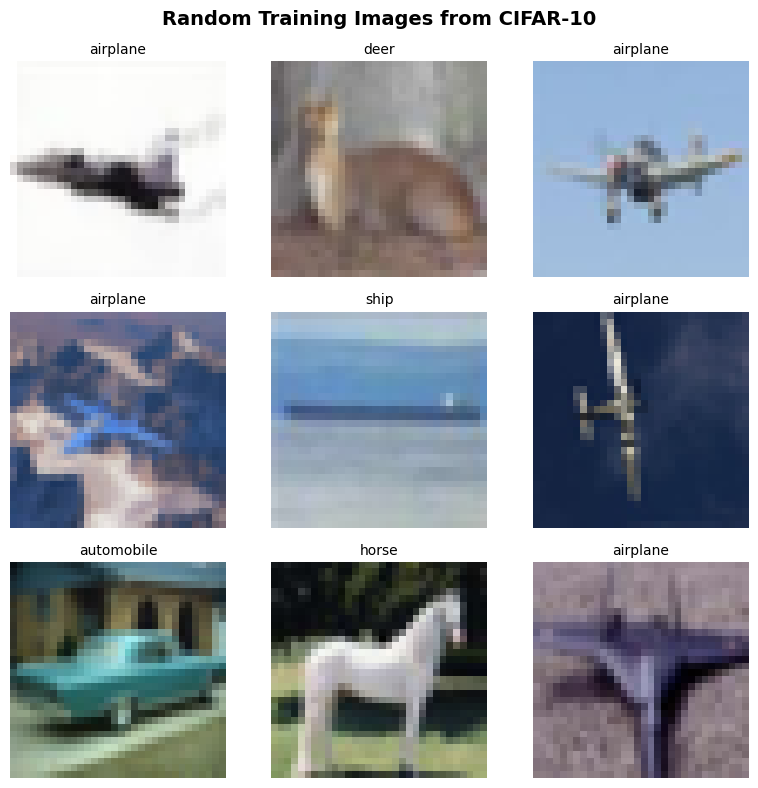

In [3]:
# Task 1.2: Display a 3x3 grid of random training images with labels

# Create a figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Random Training Images from CIFAR-10', fontsize=14, fontweight='bold')

# Get 9 random indices
indices = np.random.choice(len(x_train), 9, replace=False)

for idx, ax in enumerate(axes.flat):
    image_data = x_train[indices[idx]]
    ax.imshow(image_data)
    ax.set_title(class_names[y_train[indices[idx]][0]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Task 1.3: Print pixel value statistics before and after normalization

print("=== Before Normalization (Raw pixels) ===")
print(f"Min: {x_train.min()}")
print(f"Max: {x_train.max()}")
print(f"Mean: {x_train.mean():.4f}")
print(f"Std: {x_train.std():.4f}")

print("\n=== After ToTensor [0-1] ===")
print(f"Min: {x_train_normalized.min():.4f}")
print(f"Max: {x_train_normalized.max():.4f}")
print(f"Mean: {x_train_normalized.mean():.4f}")
print(f"Std: {x_train_normalized.std():.4f}")

print(f"\n=== After Normalize(mean={cifar_mean:.4f}, std={cifar_std:.4f}) ===")
print(f"Min: {x_train_final.min():.4f}")
print(f"Max: {x_train_final.max():.4f}")
print(f"Mean: {x_train_final.mean():.4f}")
print(f"Std: {x_train_final.std():.4f}")

=== Before Normalization (Raw pixels) ===
Min: 0
Max: 255
Mean: 120.7076
Std: 64.1501

=== After ToTensor [0-1] ===
Min: 0.0000
Max: 1.0000
Mean: 0.4734
Std: 0.2516

=== After Normalize(mean=0.4734, std=0.2516) ===
Min: -1.8816
Max: 2.0934
Mean: -0.0000
Std: 1.0000


## Task 2: Preprocessing — Train / Validation Split

In [5]:
# Task 2.1: Create train/validation split
# Use 50,000 training images: 45,000 train + 5,000 validation

val_size = 5000
x_val        = x_train_final[:val_size]
y_val        = y_train[:val_size]
x_train_split = x_train_final[val_size:]
y_train_split = y_train[val_size:]

# Convert labels to one-hot encoding for categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train_split, 10)
y_val_cat   = keras.utils.to_categorical(y_val, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

print(f"Training set:   {x_train_split.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test set:       {x_test_final.shape}")

Training set:   (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set:       (10000, 32, 32, 3)


## Task 3: CNN Architecture (Simple Sequential Model)

In [6]:
# Task 3.1: Build a Sequential model with 2 convolutional blocks
# Block structure: Conv2D(filters, (3,3), padding='same') -> BatchNorm -> ReLU -> MaxPooling2D(2)

def build_cifar_model():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Block 1: 32 filters
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=2),

        # Block 2: 64 filters
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=2),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128),
        layers.ReLU(),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_cifar_model()
print("Model created successfully!")

# Task 3.2: Print model.summary()
model.summary()

Model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Train and Evaluate the Model

In [7]:
# Task 4.1: Compile model with Adam optimizer (lr=0.001) and categorical crossentropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4.2: Train for 10 epochs with batch_size=64
history = model.fit(
    x_train_split, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val_cat),
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5388 - loss: 1.3016 - val_accuracy: 0.6420 - val_loss: 1.0172
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6754 - loss: 0.9235 - val_accuracy: 0.6966 - val_loss: 0.8754
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7333 - loss: 0.7586 - val_accuracy: 0.7028 - val_loss: 0.8549
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7778 - loss: 0.6398 - val_accuracy: 0.7266 - val_loss: 0.8251
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8152 - loss: 0.5302 - val_accuracy: 0.7160 - val_loss: 0.8481
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8500 - loss: 0.4287 - val_accuracy: 0.7128 - val_loss: 0.9363
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8830 - loss: 0.3369 - val_accuracy: 0.7164 - val_loss: 0.9913
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9100 - loss: 0.2585 - 

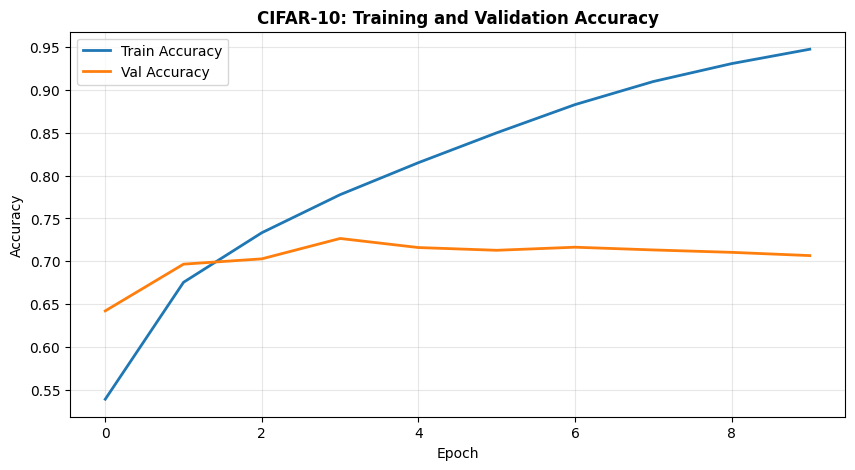

In [8]:
# Task 4.3: Plot training and validation accuracy on the same chart
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
plt.title('CIFAR-10: Training and Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Task 4.4: Evaluate on test set and print final accuracy
test_loss, test_acc = model.evaluate(x_test_final, y_test_cat, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.7003
